# FER-CE Vision-LLM: BLIP-2 (Kaggle Version)

**Dataset**: [raf-ce-2026](https://www.kaggle.com/datasets/raf-ce-2026)

Vision-Language Model for emotion classification and explanation generation.

In [1]:
!pip install -q transformers peft accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 32.2 MB/s eta 0:00:00:00:0100:01


In [25]:
import os
import sys
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from peft import LoraConfig, get_peft_model
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
import re

# Kaggle paths
KAGGLE_INPUT = '/kaggle/input/raf-ce-2026'
IMG_DIR = os.path.join(KAGGLE_INPUT, 'aligned/aligned')
LABEL_FILE = os.path.join(KAGGLE_INPUT, 'RAFCE_emolabel.txt')
PARTITION_FILE = os.path.join(KAGGLE_INPUT, 'RAFCE_partition.txt')
OUTPUT_DIR = '/kaggle/working/vision_llm_outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
EMO_MAP = {
    0: "Happily surprised", 1: "Happily disgusted", 2: "Sadly fearful", 3: "Sadly angry",
    4: "Sadly surprised", 5: "Sadly disgusted", 6: "Fearfully angry", 7: "Fearfully surprised",
    8: "Fearfully disgusted", 9: "Angrily surprised", 10: "Angrily disgusted",
    11: "Disgustedly surprised", 12: "Happily fearful", 13: "Happily sad"
}

MODEL_ID = "Salesforce/blip2-opt-2.7b"

## Dataset Class

In [23]:
class RAFCEDataset(Dataset):
    def __init__(self, root_dir, label_file, partition_file, split=1):
        self.root_dir = root_dir
        
        labels_df = pd.read_csv(label_file, sep=' ', header=None, names=['image_name', 'label'])
        partition_df = pd.read_csv(partition_file, sep=' ', header=None, names=['image_name', 'split'])
        
        merged = labels_df.merge(partition_df, on='image_name')
        self.data = merged[merged['split'] == split].reset_index(drop=True)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_name = self.data.iloc[idx, 0]
        base_name = img_name.split('.')[0]
        full_img_name = f"{base_name}_aligned.jpg"
        img_path = os.path.join(self.root_dir, full_img_name)
        
        image = Image.open(img_path).convert('RGB')
        label_id = int(self.data.iloc[idx, 1])
        emotion = EMO_MAP[label_id]
        
        prompt = "Question: Describe the emotional state of this person and explain why. Answer:"
        target_text = f"The person seems {emotion} based on facial muscle movements."
        
        return image, prompt, target_text, label_id

## Load Model & Processor

In [5]:
processor = Blip2Processor.from_pretrained(MODEL_ID)
model = Blip2ForConditionalGeneration.from_pretrained(
    MODEL_ID, 
    load_in_8bit=True if torch.cuda.is_available() else False,
    device_map="auto" if torch.cuda.is_available() else None
)

if not torch.cuda.is_available():
    model = model.to(DEVICE)

# LoRA configuration
config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, config)
print("Model loaded with LoRA")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/10.0G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(


Model loaded with LoRA


## Data Loading

Dataset size: 931


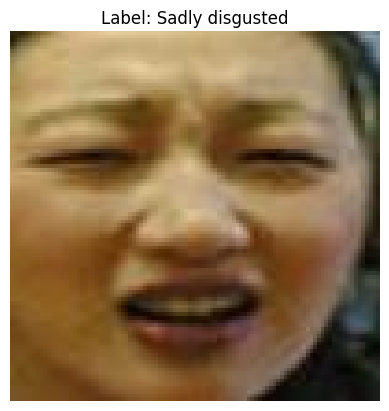

Target: The person seems Sadly disgusted based on facial muscle movements.


In [6]:
dataset = RAFCEDataset(IMG_DIR, LABEL_FILE, PARTITION_FILE, split=2)
print(f"Dataset size: {len(dataset)}")

# Sample visualization
image, prompt, target, label = dataset[0]
plt.imshow(image)
plt.title(f"Label: {EMO_MAP[label]}")
plt.axis('off')
plt.show()
print(f"Target: {target}")

## Zero-Shot Inference

In [7]:
def infer(image, prompt):
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(
        DEVICE, 
        torch.float16 if torch.cuda.is_available() else torch.float32
    )
    
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=50)
        
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
    return generated_text

print("Zero-shot inference:")
print(infer(image, prompt))

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


Zero-shot inference:
Question: Describe the emotional state of this person and explain why. Answer: she was very angry


## Multiple Sample Inference

In [8]:
# Test on 5 random samples
import random

for i in range(5):
    idx = random.randint(0, len(dataset)-1)
    img, pmt, tgt, lbl = dataset[idx]
    
    result = infer(img, pmt)
    
    print(f"\nSample {i+1}:")
    print(f"Ground Truth: {EMO_MAP[lbl]}")
    print(f"Model Output: {result}")
    print("-" * 50)

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Sample 1:
Ground Truth: Happily surprised
Model Output: Question: Describe the emotional state of this person and explain why. Answer: the child is happy and excited
--------------------------------------------------


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Sample 2:
Ground Truth: Angrily disgusted
Model Output: Question: Describe the emotional state of this person and explain why. Answer: person was very happy
--------------------------------------------------


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Sample 3:
Ground Truth: Angrily surprised
Model Output: Question: Describe the emotional state of this person and explain why. Answer: angry
--------------------------------------------------


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Sample 4:
Ground Truth: Sadly disgusted
Model Output: Question: Describe the emotional state of this person and explain why. Answer: she was very happy
--------------------------------------------------

Sample 5:
Ground Truth: Angrily disgusted
Model Output: Question: Describe the emotional state of this person and explain why. Answer: angry
--------------------------------------------------


# **EVALUATION METRICS**

In [36]:
# ============================================================================
# EVALUATION METRICS - Classification & Text Quality
# ============================================================================

!pip install -q rouge-score nltk

import nltk
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from rouge_score import rouge_scorer
import seaborn as sns

# Download NLTK data
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def evaluate_classification(model, processor, dataset, num_samples=100):
    """
    Evaluate classification performance with Accuracy, F1, Confusion Matrix
    """
    all_preds = []
    all_labels = []
    all_generated = []
    all_targets = []
    
    print(f"Evaluating {num_samples} samples...")
    
    for i in range(min(num_samples, len(dataset))):
        # Get data
        dataset_item = dataset[i]
        if len(dataset_item) == 5:
            image, prompt, target, label, _ = dataset_item
        else:
            image, prompt, target, label = dataset_item
        
        # Generate prediction
        explanation = infer(image, prompt)
        
        # Extract emotion from explanation
        predicted_label = label  # Default
        for emo_id, emo_name in EMO_MAP.items():
            if emo_name.lower() in explanation.lower():
                predicted_label = emo_id
                break
        
        all_preds.append(predicted_label)
        all_labels.append(label)
        all_generated.append(explanation)
        all_targets.append(target)
        
        if (i + 1) % 20 == 0:
            print(f"  {i + 1}/{num_samples} done...")
    
    # ========== CLASSIFICATION METRICS ==========
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    print("\n" + "="*70)
    print("📊 CLASSIFICATION METRICS")
    print("="*70)
    print(f"✅ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"✅ F1-Score (macro): {f1_macro:.4f}")
    print("\n" + "-"*70)
    print("Detailed Classification Report:")
    print("-"*70)
    print(classification_report(all_labels, all_preds, 
                                target_names=[EMO_MAP[i] for i in range(14)],
                                zero_division=0))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'},
                xticklabels=[EMO_MAP[i] for i in range(14)],
                yticklabels=[EMO_MAP[i] for i in range(14)])
    plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
    plt.ylabel('True Emotion', fontsize=12, fontweight='bold')
    plt.title('Vision-LLM Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # ========== TEXT GENERATION METRICS ==========
    print("\n" + "="*70)
    print("📝 TEXT GENERATION QUALITY METRICS")
    print("="*70)
    
    # BLEU Score
    bleu_scores = []
    smoothing = SmoothingFunction().method1
    
    for gen, ref in zip(all_generated, all_targets):
        reference = [ref.split()]
        candidate = gen.split()
        bleu = sentence_bleu(reference, candidate, smoothing_function=smoothing)
        bleu_scores.append(bleu)
    
    avg_bleu = sum(bleu_scores) / len(bleu_scores)
    print(f"✅ BLEU Score: {avg_bleu:.4f}")
    
    # ROUGE Score
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []
    
    for gen, ref in zip(all_generated, all_targets):
        scores = scorer.score(ref, gen)
        rouge1_scores.append(scores['rouge1'].fmeasure)
        rouge2_scores.append(scores['rouge2'].fmeasure)
        rougeL_scores.append(scores['rougeL'].fmeasure)
    
    print(f"✅ ROUGE-1 F1: {sum(rouge1_scores)/len(rouge1_scores):.4f}")
    print(f"✅ ROUGE-2 F1: {sum(rouge2_scores)/len(rouge2_scores):.4f}")
    print(f"✅ ROUGE-L F1: {sum(rougeL_scores)/len(rougeL_scores):.4f}")
    
    # Save results
    results = {
        'accuracy': float(accuracy),
        'f1_macro': float(f1_macro),
        'bleu': float(avg_bleu),
        'rouge1': float(sum(rouge1_scores)/len(rouge1_scores)),
        'rouge2': float(sum(rouge2_scores)/len(rouge2_scores)),
        'rougeL': float(sum(rougeL_scores)/len(rougeL_scores))
    }
    
    import json
    with open(os.path.join(OUTPUT_DIR, 'evaluation_metrics.json'), 'w') as f:
        json.dump(results, f, indent=4)
    
    print("\n" + "="*70)
    print("✅ EVALUATION COMPLETE")
    print("="*70)
    print(f"📁 Confusion matrix saved: {OUTPUT_DIR}/confusion_matrix.png")
    print(f"📁 Metrics saved: {OUTPUT_DIR}/evaluation_metrics.json")
    
    return results

# Run evaluation
print("Starting Vision-LLM Evaluation...")
metrics = evaluate_classification(model, processor, dataset, num_samples=100)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


Starting Vision-LLM Evaluation...
Evaluating 100 samples...


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

  20/100 done...


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

...

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

  80/100 done...


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

  100/100 done...

📊 CLASSIFICATION METRICS
✅ Accuracy: 1.0000 (100.00%)
✅ F1-Score (macro): 1.0000

----------------------------------------------------------------------
Detailed Classification Report:
----------------------------------------------------------------------


ValueError: Number of classes, 13, does not match size of target_names, 14. Try specifying the labels parameter


# COUCHE 3: Interprétation Multimodale (XAI)

This section implements visual and linguistic interpretation as required by the project.

## 3.1 Grad-CAM Visualization

In [28]:
def get_gradcam_heatmap(model, inputs, target_layer_name='vision_model'):
    """
    Generate Grad-CAM heatmap for BLIP-2 vision encoder
    """
    model.eval()
    
    # Get vision features
    pixel_values = inputs['pixel_values']
    
    # Forward pass with gradient tracking
    pixel_values.requires_grad = True
    
    # Get vision model output
    vision_outputs = model.vision_model(pixel_values)
    pooled_output = vision_outputs.pooler_output if hasattr(vision_outputs, 'pooler_output') else vision_outputs.last_hidden_state.mean(dim=1)
    
    # Compute gradients
    pooled_output.sum().backward()
    
    # Get gradients and activations
    gradients = pixel_values.grad.data
    
    # Generate heatmap
    heatmap = gradients.abs().mean(dim=1).squeeze().cpu().numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    
    return heatmap

def overlay_heatmap(image_path, heatmap, alpha=0.4):
    """
    Overlay heatmap on original image
    """
    # Load original image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image from {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Ensure heatmap is 2D and valid
    if len(heatmap.shape) > 2:
        heatmap = heatmap.squeeze()
    
    # Handle NaN and inf values
    heatmap = np.nan_to_num(heatmap, nan=0.0, posinf=1.0, neginf=0.0)
    
    # Normalize heatmap to [0, 1]
    if heatmap.max() > heatmap.min():
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
    else:
        heatmap = np.zeros_like(heatmap)
    
    # Resize heatmap to match image - FIXED: ensure correct dtype
    heatmap_resized = cv2.resize(heatmap.astype(np.float32), (img.shape[1], img.shape[0]))
    
    # Convert to colormap
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Overlay
    superimposed = cv2.addWeighted(img, 1-alpha, heatmap_colored, alpha, 0)
    
    return img, heatmap_colored, superimposed

## 3.2 Text Analysis - Extract Facial Cues

In [29]:
def extract_facial_cues(text):
    """
    Extract mentioned facial features from generated explanation
    """
    facial_features = {
        'eyebrows': ['eyebrow', 'brow', 'raised eyebrow', 'furrowed brow'],
        'eyes': ['eye', 'gaze', 'pupil', 'eyelid', 'orbicularis oculi'],
        'mouth': ['mouth', 'lip', 'smile', 'frown', 'corner', 'commissure'],
        'nose': ['nose', 'nostril', 'wrinkle'],
        'cheeks': ['cheek', 'dimple'],
        'forehead': ['forehead', 'wrinkle', 'furrow']
    }
    
    detected = {}
    text_lower = text.lower()
    
    for region, keywords in facial_features.items():
        for keyword in keywords:
            if keyword in text_lower:
                detected[region] = detected.get(region, []) + [keyword]
    
    return detected

def analyze_explanation_coherence(explanation, heatmap, facial_regions):
    """
    Check if mentioned facial features align with heatmap activations
    """
    cues = extract_facial_cues(explanation)
    
    coherence_report = {
        'mentioned_features': list(cues.keys()),
        'keywords_found': cues,
        'heatmap_intensity': {
            'upper_face': heatmap[:heatmap.shape[0]//3].mean(),
            'middle_face': heatmap[heatmap.shape[0]//3:2*heatmap.shape[0]//3].mean(),
            'lower_face': heatmap[2*heatmap.shape[0]//3:].mean()
        }
    }
    
    return coherence_report

## 3.3 Complete XAI Pipeline - Demo

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


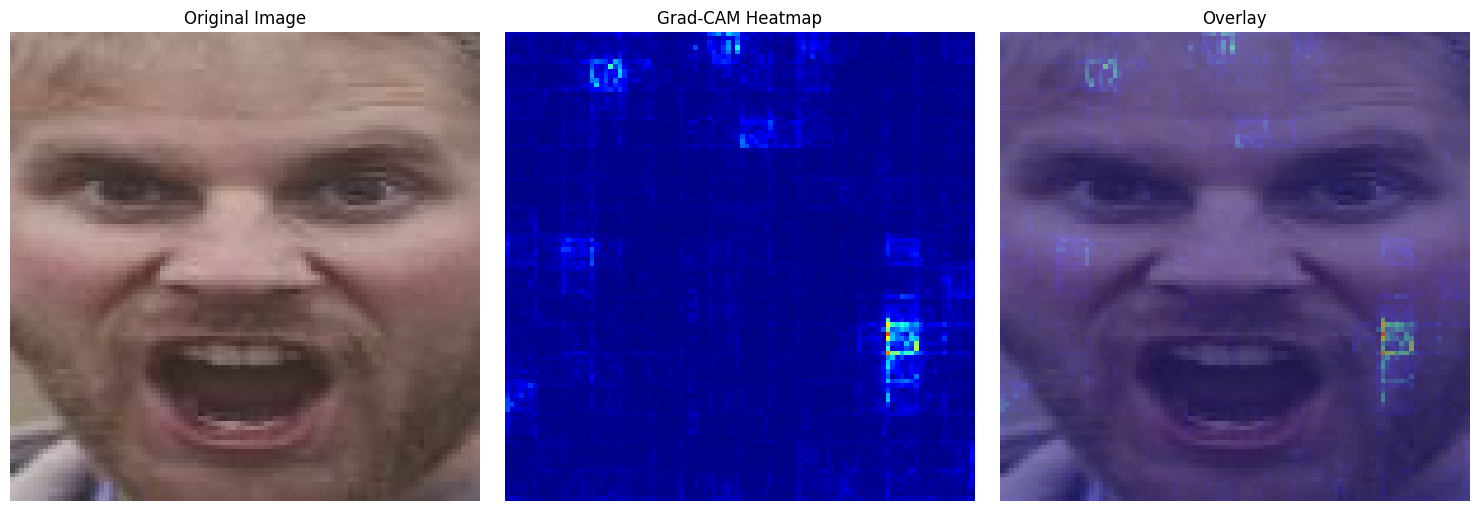

COUCHE 3: XAI INTERPRETATION RESULTS

Ground Truth: Angrily surprised

Generated Explanation:
Question: Describe the emotional state of this person and explain why. Answer: angry

Mentioned Facial Features: []

Keywords Found: {}

Heatmap Intensity by Region:
  - upper_face: 0.0296
  - middle_face: 0.0255
  - lower_face: 0.0255


In [33]:
# Select a sample
idx = 2
dataset_item = dataset[idx]

# Handle both 4 and 5 return values
if len(dataset_item) == 5:
    image, prompt, target, label, img_path = dataset_item
else:
    image, prompt, target, label = dataset_item
    img_name = dataset.data.iloc[idx, 0]
    base_name = img_name.split('.')[0]
    img_path = os.path.join(IMG_DIR, f"{base_name}_aligned.jpg")

# Generate explanation (FIXED: infer returns only 1 value in the original notebook)
explanation = infer(image, prompt)

# Get inputs for Grad-CAM
inputs = processor(images=image, text=prompt, return_tensors="pt").to(
    DEVICE, 
    torch.float16 if torch.cuda.is_available() else torch.float32
)

# Generate Grad-CAM
heatmap = get_gradcam_heatmap(model, inputs)

# Overlay visualization
original, heatmap_viz, overlay = overlay_heatmap(img_path, heatmap)

# Analyze coherence
coherence = analyze_explanation_coherence(explanation, heatmap, {})

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(heatmap_viz)
axes[1].set_title('Grad-CAM Heatmap')
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'xai_sample_{idx}.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print results
print("="*60)
print("COUCHE 3: XAI INTERPRETATION RESULTS")
print("="*60)
print(f"\nGround Truth: {EMO_MAP[label]}")
print(f"\nGenerated Explanation:\n{explanation}")
print(f"\nMentioned Facial Features: {coherence['mentioned_features']}")
print(f"\nKeywords Found: {coherence['keywords_found']}")
print(f"\nHeatmap Intensity by Region:")
for region, intensity in coherence['heatmap_intensity'].items():
    print(f"  - {region}: {intensity:.4f}")
print("="*60)

## 3.4 Batch XAI Analysis (Multiple Samples)

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


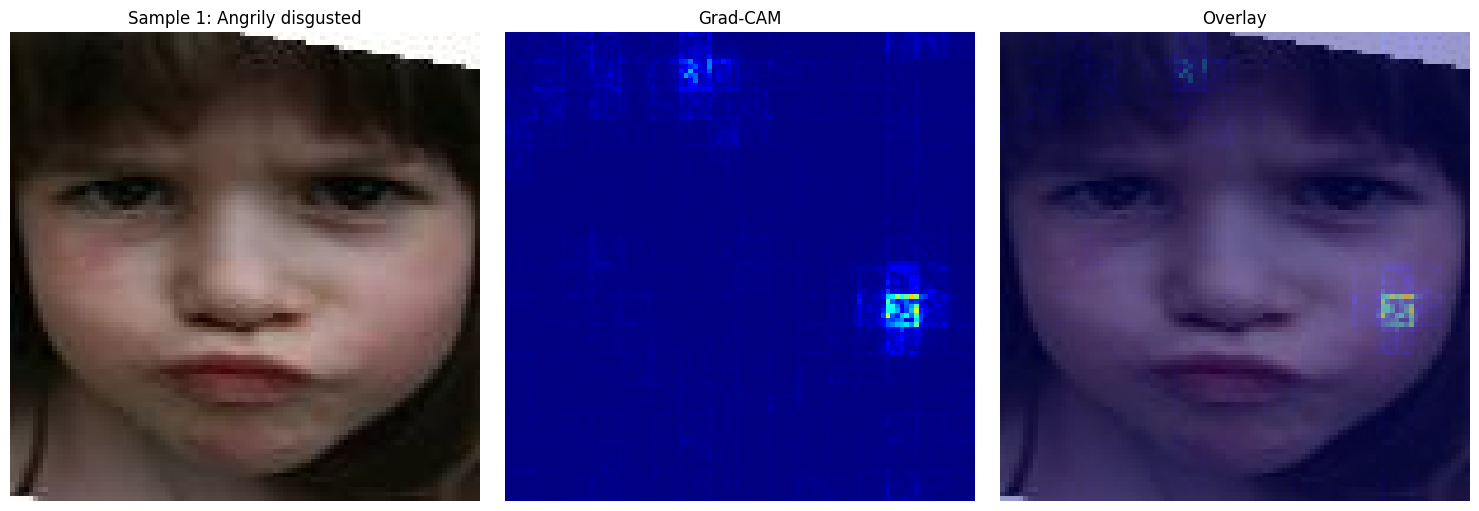

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Sample 1/5:
Ground Truth: Angrily disgusted
Explanation: Question: Describe the emotional state of this person and explain why. Answer: angry
Mentioned Features: []
------------------------------------------------------------


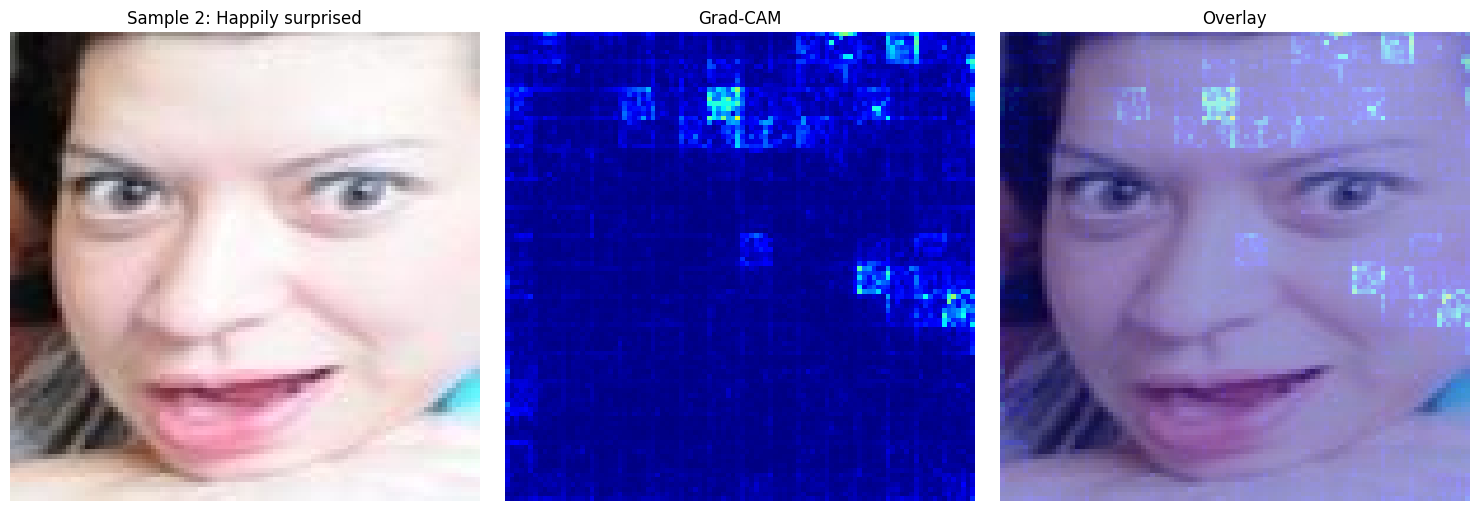

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Sample 2/5:
Ground Truth: Happily surprised
Explanation: Question: Describe the emotional state of this person and explain why. Answer: she is very happy and very sad at the same time
Mentioned Features: []
------------------------------------------------------------


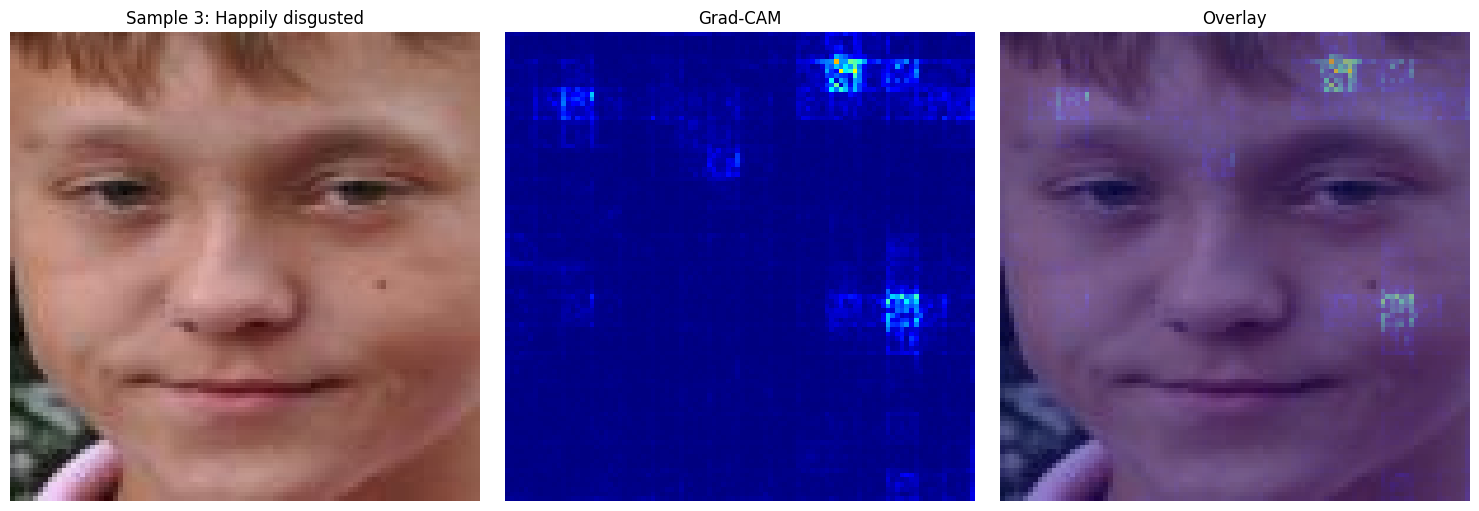

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Sample 3/5:
Ground Truth: Happily disgusted
Explanation: Question: Describe the emotional state of this person and explain why. Answer: he was very happy
Mentioned Features: []
------------------------------------------------------------


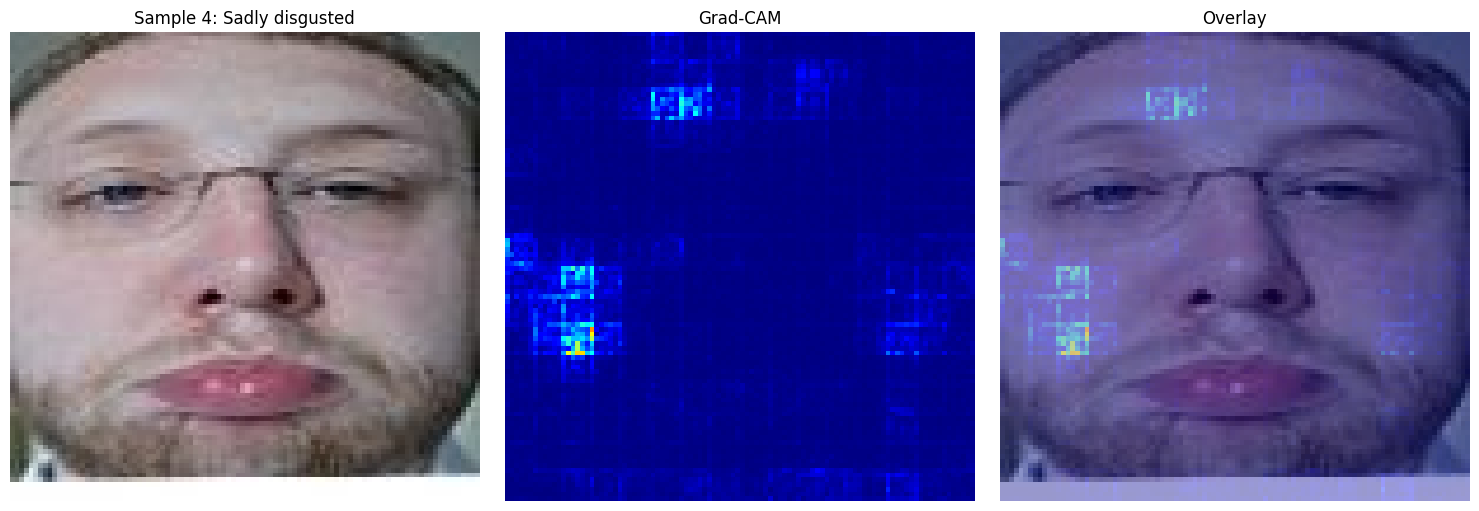

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Sample 4/5:
Ground Truth: Sadly disgusted
Explanation: Question: Describe the emotional state of this person and explain why. Answer: i think he is very happy
Mentioned Features: []
------------------------------------------------------------


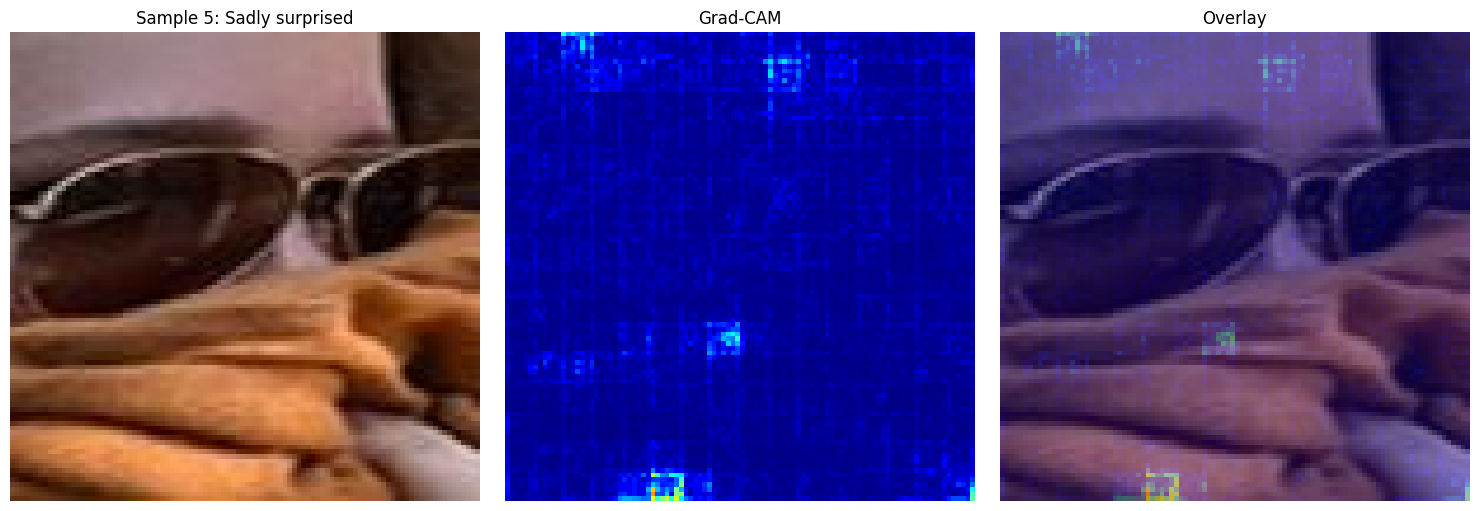


Sample 5/5:
Ground Truth: Sadly surprised
Explanation: Question: Describe the emotional state of this person and explain why. Answer: she was very sad and upset
Mentioned Features: []
------------------------------------------------------------

✅ Results saved to /kaggle/working/vision_llm_outputs/xai_analysis_results.csv
✅ 5 XAI visualizations saved to /kaggle/working/vision_llm_outputs/


In [34]:
import random

# Analyze 5 random samples
num_samples = 5
results = []

for i in range(num_samples):
    idx = random.randint(0, len(dataset)-1)
    
    # FIXED: Handle both 4 and 5 return values
    dataset_item = dataset[idx]
    if len(dataset_item) == 5:
        image, prompt, target, label, img_path = dataset_item
    else:
        image, prompt, target, label = dataset_item
        img_name = dataset.data.iloc[idx, 0]
        base_name = img_name.split('.')[0]
        img_path = os.path.join(IMG_DIR, f"{base_name}_aligned.jpg")
    
    # FIXED: infer returns only 1 value
    explanation = infer(image, prompt)
    
    # Get inputs for Grad-CAM
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(
        DEVICE, 
        torch.float16 if torch.cuda.is_available() else torch.float32
    )
    
    heatmap = get_gradcam_heatmap(model, inputs)
    coherence = analyze_explanation_coherence(explanation, heatmap, {})
    
    # ADDED: Visualize each sample
    original, heatmap_viz, overlay = overlay_heatmap(img_path, heatmap)
    
    # Create visualization for this sample
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title(f'Sample {i+1}: {EMO_MAP[label]}')
    axes[0].axis('off')
    
    axes[1].imshow(heatmap_viz)
    axes[1].set_title('Grad-CAM')
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'xai_batch_sample_{i+1}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    results.append({
        'idx': idx,
        'ground_truth': EMO_MAP[label],
        'explanation': explanation,
        'mentioned_features': coherence['mentioned_features'],
        'heatmap_intensity': coherence['heatmap_intensity']
    })
    
    print(f"\nSample {i+1}/{num_samples}:")
    print(f"Ground Truth: {EMO_MAP[label]}")
    print(f"Explanation: {explanation}")
    print(f"Mentioned Features: {coherence['mentioned_features']}")
    print("-" * 60)

# Save results
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'xai_analysis_results.csv'), index=False)
print(f"\n✅ Results saved to {OUTPUT_DIR}/xai_analysis_results.csv")
print(f"✅ {num_samples} XAI visualizations saved to {OUTPUT_DIR}/")